# 02 — Quantum Data Encoding (PennyLane)
### QML Curriculum · Companion Notebook to Module 8 — *Quantum Data Encoding*

**Part of:** [Schrödinger's Cats — Quantum Machine Learning Platform](https://tanjinadnanabir.github.io/WISER-Education-Challenge/)

Every QML pipeline starts with the same question: **how do you get classical data — numbers, pixels, features — into a quantum circuit?** This is the "quantum data encoding" step, and it's arguably the single most important design choice in any QML model.

We now switch from Qiskit to **PennyLane** — the framework built specifically for QML, with automatic differentiation baked in.

**By the end of this notebook you will be able to:**
- Implement **basis encoding** (binary data → computational basis states)
- Implement **angle encoding** (features → rotation angles)
- Implement **amplitude encoding** (a full feature vector → one quantum state)
- Build a simple **feature map** and reason about **data re-uploading**

**Prerequisites:** Notebook 01, Module 5 (gates & circuits), Module 8 (conceptual).


In [1]:
# Setup
import pennylane as qml
from pennylane import numpy as pnp
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)
print("PennyLane version:", qml.__version__)

PennyLane version: 0.45.1


## 1. Basis Encoding — Bits Straight into Qubits

The simplest encoding imaginable: a classical bit string like `1011` becomes the computational basis state `|1011⟩`. Each bit gets exactly one qubit, flipped with an `X` gate if the bit is `1`.

**Tradeoff:** dead simple, but needs as many qubits as bits — no compression at all.

In [2]:
def basis_encoding_circuit(bitstring):
    n = len(bitstring)
    dev = qml.device("default.qubit", wires=n)

    @qml.qnode(dev)
    def circuit():
        for i, bit in enumerate(bitstring):
            if bit == '1':
                qml.PauliX(wires=i)
        return qml.state()

    return circuit

bits = "1011"
circuit = basis_encoding_circuit(bits)
state = circuit()
print(f"Bitstring {bits} -> nonzero amplitude at index {np.argmax(np.abs(state))} "
      f"(binary {bits}), amplitude = {state[np.argmax(np.abs(state))]:.2f}")
print(qml.draw(circuit)())

Bitstring 1011 -> nonzero amplitude at index 11 (binary 1011), amplitude = 1.00+0.00j
0: ──X─┤  State
2: ──X─┤  State
3: ──X─┤  State


## 2. Angle Encoding — Features as Rotation Angles

The workhorse encoding for QML. Each classical feature `x_i` becomes a **rotation angle** on its own qubit, usually via `RY(x_i)` or `RX(x_i)`.

**Tradeoff:** one qubit per feature (better than basis encoding for continuous data), and it's naturally differentiable — perfect for gradient-based training in later notebooks.

In [3]:
def angle_encoding_circuit(features, rotation="Y"):
    n = len(features)
    dev = qml.device("default.qubit", wires=n)

    @qml.qnode(dev)
    def circuit():
        for i, x in enumerate(features):
            if rotation == "Y":
                qml.RY(x, wires=i)
            elif rotation == "X":
                qml.RX(x, wires=i)
            elif rotation == "Z":
                qml.RZ(x, wires=i)
        return [qml.expval(qml.PauliZ(w)) for w in range(n)]

    return circuit

features = np.array([0.1, 1.2, 2.4, np.pi])
circuit = angle_encoding_circuit(features)
print("Input features:", features)
print("<Z> expectation per qubit after encoding:", circuit())
print()
print(qml.draw(circuit)())

Input features: [0.1   1.2   2.4   3.142]
<Z> expectation per qubit after encoding: [np.float64(0.9950041652780259), np.float64(0.3623577544766737), np.float64(-0.7373937155412454), np.float64(-1.0000000000000002)]

0: ──RY(0.10)─┤  <Z>
1: ──RY(1.20)─┤  <Z>
2: ──RY(2.40)─┤  <Z>
3: ──RY(3.14)─┤  <Z>


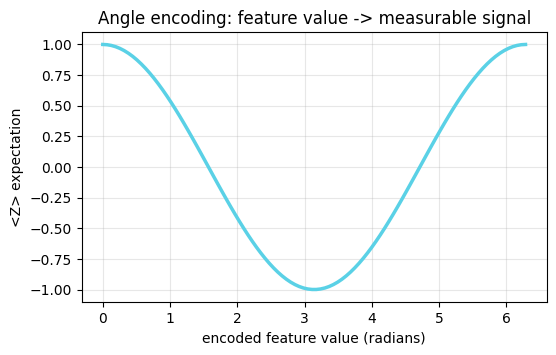

In [4]:
# Visualize: as a feature value sweeps 0 -> 2*pi, watch <Z> trace out a cosine curve.
# This is literally the mechanism angle encoding uses to represent continuous values.
xs = np.linspace(0, 2 * np.pi, 100)
dev1 = qml.device("default.qubit", wires=1)

@qml.qnode(dev1)
def single_angle(x):
    qml.RY(x, wires=0)
    return qml.expval(qml.PauliZ(0))

ys = [single_angle(x) for x in xs]

plt.figure(figsize=(6, 3.5))
plt.plot(xs, ys, color="#5ad1e6", linewidth=2.5)
plt.xlabel("encoded feature value (radians)")
plt.ylabel("<Z> expectation")
plt.title("Angle encoding: feature value -> measurable signal")
plt.grid(alpha=0.3)
plt.show()

## 3. Amplitude Encoding — Squeezing a Whole Vector into One State

The most qubit-efficient encoding: an entire normalized feature vector of length `2^n` is loaded directly as the **amplitudes** of an `n`-qubit state.

**Tradeoff:** exponential compression (`2^n` numbers into `n` qubits!) — but in practice, loading arbitrary amplitudes efficiently on real hardware is itself a hard, active research problem. On a simulator, PennyLane does it for us with one template.

In [5]:
from pennylane.templates import AmplitudeEmbedding

# A feature vector of length 4 fits exactly into 2 qubits (2^2 = 4)
raw_vector = np.array([1.0, 2.0, 3.0, 4.0])
normalized = raw_vector / np.linalg.norm(raw_vector)
print("Raw feature vector:  ", raw_vector)
print("Normalized (unit length, required for a valid quantum state):", normalized.round(3))

dev2 = qml.device("default.qubit", wires=2)

@qml.qnode(dev2)
def amplitude_circuit(vec):
    AmplitudeEmbedding(features=vec, wires=[0, 1], normalize=True)
    return qml.state()

encoded_state = amplitude_circuit(raw_vector)
print("\nResulting quantum state amplitudes:", np.real(encoded_state).round(3))
print("Compare to normalized input:        ", normalized.round(3))
print("\nMatch:", np.allclose(np.real(encoded_state), normalized))

Raw feature vector:   [1. 2. 3. 4.]
Normalized (unit length, required for a valid quantum state): [0.183 0.365 0.548 0.73 ]

Resulting quantum state amplitudes: [0.183 0.365 0.548 0.73 ]
Compare to normalized input:         [0.183 0.365 0.548 0.73 ]

Match: True


### 🔧 Try it yourself
`AmplitudeEmbedding` needs exactly `2^n` numbers for `n` qubits. Fix the cell below — pad `raw_vector` with a zero so it has length 8, then encode it on **3** qubits.

In [6]:
raw_vector = np.array([1.0, 0.5, 2.0])  # length 3 -- not a power of 2!
# YOUR CODE HERE: pad raw_vector to length 8 (e.g. np.pad or np.append with zeros)


dev3 = qml.device("default.qubit", wires=3)

@qml.qnode(dev3)
def amp3(vec):
    AmplitudeEmbedding(features=vec, wires=[0, 1, 2], normalize=True, pad_with=0.0)
    return qml.state()

# Uncomment once your vector has length 8:
# print(amp3(raw_vector).round(3))

## 4. Feature Maps — Encoding *and* Entangling

A **feature map** goes one step further than plain angle encoding: after rotating each qubit by its feature value, it **entangles** the qubits together. This lets the quantum circuit represent correlations *between* features — not just each feature in isolation — which is exactly where a quantum advantage in expressivity is hypothesized to live.

This is the standard "ZZ feature map" style building block used by quantum kernel methods (Notebook 04).

In [7]:
def zz_feature_map(features, wires):
    n = len(wires)
    for i in range(n):
        qml.Hadamard(wires=wires[i])
        qml.RZ(2 * features[i], wires=wires[i])
    for i in range(n - 1):
        qml.CNOT(wires=[wires[i], wires[i + 1]])
        qml.RZ(2 * (np.pi - features[i]) * (np.pi - features[i + 1]), wires=wires[i + 1])
        qml.CNOT(wires=[wires[i], wires[i + 1]])

dev4 = qml.device("default.qubit", wires=3)

@qml.qnode(dev4)
def feature_map_circuit(x):
    zz_feature_map(x, wires=[0, 1, 2])
    return qml.state()

x_sample = np.array([0.3, 0.8, 1.5])
print(qml.draw(feature_map_circuit)(x_sample))
print("\nNotice the CNOTs: this is what makes it a feature map rather than plain angle encoding --")
print("qubit 1's final state now depends on qubit 0's feature value too.")

0: ──H──RZ(0.60)─╭●────────────╭●─────────────────┤  State
1: ──H──RZ(1.60)─╰X──RZ(13.31)─╰X─╭●───────────╭●─┤  State
2: ──H──RZ(3.00)──────────────────╰X──RZ(7.69)─╰X─┤  State

Notice the CNOTs: this is what makes it a feature map rather than plain angle encoding --
qubit 1's final state now depends on qubit 0's feature value too.


## 5. Data Re-uploading — One Qubit, Many Passes

A neat trick for when you have few qubits: instead of one encoding pass, **re-upload** the same data multiple times, interleaved with trainable gates. Each pass lets the circuit build a richer function of the input — conceptually similar to stacking layers in a classical neural network.

In [8]:
dev5 = qml.device("default.qubit", wires=1)

@qml.qnode(dev5)
def reuploading_circuit(x, weights, n_layers=3):
    for layer in range(n_layers):
        qml.RY(x, wires=0)                 # re-upload the same data point
        qml.RZ(weights[layer], wires=0)    # trainable parameter, unique per layer
    return qml.expval(qml.PauliZ(0))

x_val = 1.0
weights = pnp.array([0.1, 0.5, 0.9], requires_grad=True)
print("Output with 3 re-uploading layers:", reuploading_circuit(x_val, weights))
print(qml.draw(reuploading_circuit)(x_val, weights, n_layers=3))
print("\nEach 'RY(x)' block re-injects the same input -- more layers, more expressive power,")
print("without needing more qubits. You'll train circuits shaped exactly like this in Notebook 03.")

Output with 3 re-uploading layers: -0.8588462372017983
0: ──RY(1.00)──RZ(0.10)──RY(1.00)──RZ(0.50)──RY(1.00)──RZ(0.90)─┤  <Z>

Each 'RY(x)' block re-injects the same input -- more layers, more expressive power,
without needing more qubits. You'll train circuits shaped exactly like this in Notebook 03.


## 6. Recap & What's Next

| Encoding | Qubits needed | Best for |
|---|---|---|
| **Basis** | 1 per bit | Small, discrete/binary data |
| **Angle** | 1 per feature | Continuous features, easy to differentiate |
| **Amplitude** | log₂(N) for N features | Maximum qubit compression |
| **Feature map** | 1 per feature (+ entangling gates) | Capturing feature *correlations* |
| **Data re-uploading** | as few as 1 | Squeezing expressivity from very few qubits |

**Next notebook: `03_variational_circuits_qnn.ipynb`** — Module 9. You'll take the angle-encoding building block from this notebook and wrap it with **trainable** gates, turning it into your first Quantum Neural Network.
